# 

In [14]:
%load_ext autoreload
%autoreload 2

from report import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
job_dict = {
    #"Baseline" : "../results/job_14649999"
    #"Baseline" : "../results/job_14657724", #ReLU
    #"Baseline" : "../results/job_15013579", #Leaky ReLU
    #"Baseline" : "../results/job_15019651", #Leaky ReLU Softplus
    #"Baseline" : "../results/job_15032242", #Leaky ReLU Softplus SLOW
    #"Baseline" : "../results/job_15075017", #Reverted to better likelihood calculation
    #"Baseline": "../results/job_15086159", #Less kl and more adabelief
    #"Baseline": "../results/job_15430938", #Golden parameters
    #"Baseline": "../results/job_15444520", #Golden parameters
    #"Baseline": "../results/job_15466102", #oof do over
    #"Baseline": "../results/job_15958064", 
    #"More KL": "../results/job_15958110", #kl=1e1
    #"Student" : "../results/job_15983920", #Student's t = 32
    #"Baseline": "../results/job_16487288", 
    "Baseline": "../results/job_16491256", #lognormal t 32
    "Adam": "../results/job_16621855",
}
jr = JobReport(*job_dict.values(), names=list(job_dict.keys()))

# benchmarks for which we have a baseline 
baseline = jr.results[jr.results.name=='Baseline']
filtered = jr.results[jr.results.Benchmark.isin(baseline.Benchmark)]

# Exclude multi-wilson. you can comment this out to include
filtered = filtered[~filtered.Benchmark.str.contains('multi_wilson')]


<>:57: SyntaxWarning: invalid escape sequence '\s'
<>:57: SyntaxWarning: invalid escape sequence '\s'
/lscratch/kmdalton/tmp/ipykernel_1774224/1981992959.py:57: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("Anomalous Peak Height ($\sigma$)")


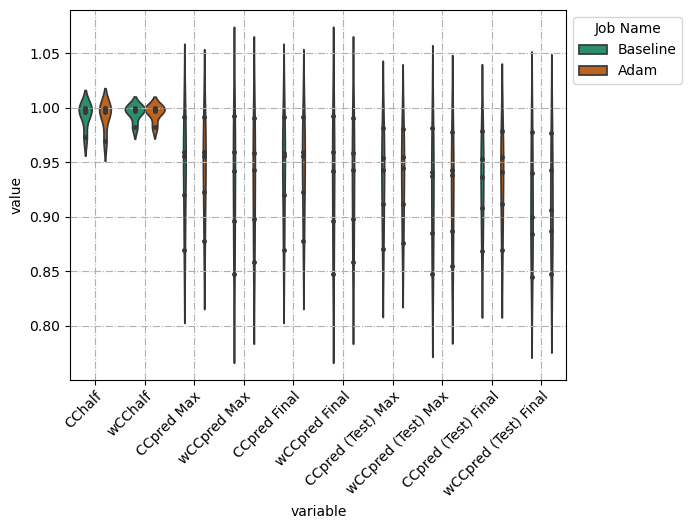

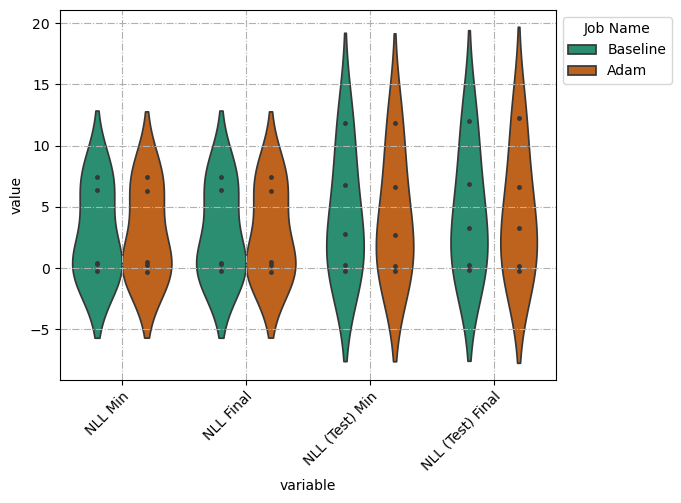

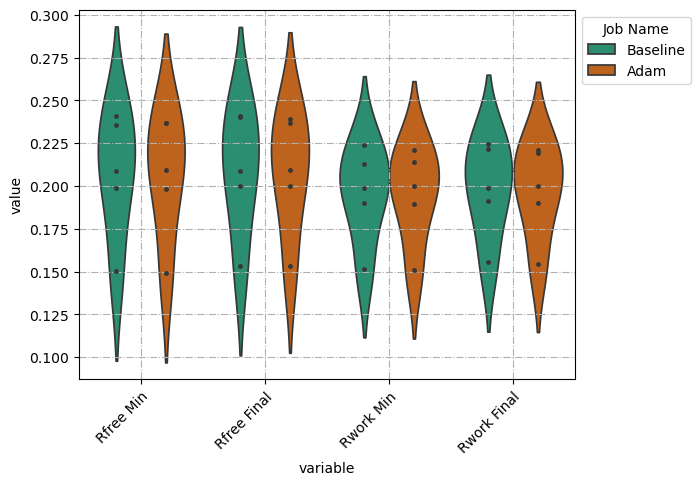

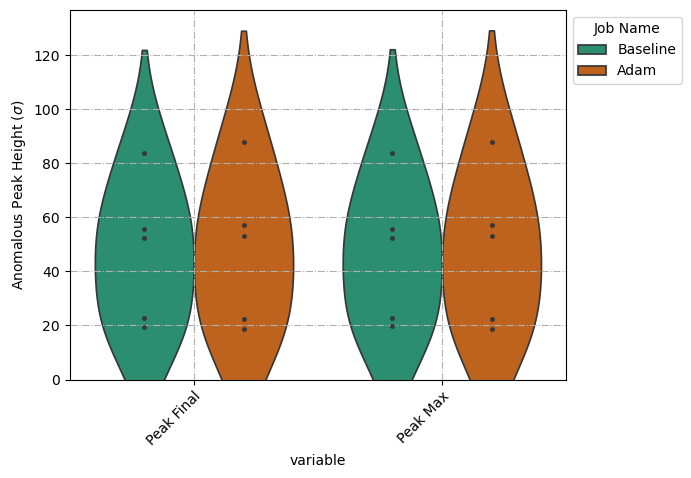

In [16]:
plt.figure()
plot_data = filtered
keys = ['Job Name'] + [k for k in plot_data if 'CC' in k]
sns.violinplot(
    plot_data[keys].melt('Job Name'),
    hue = 'Job Name',
    x = 'variable',
    y = 'value',
    inner='point',
    palette='Dark2',
)
plt.grid(ls='-.')
plt.xticks(rotation=45, rotation_mode='anchor', ha='right')
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))

plt.figure()
plot_data = filtered
keys = ['Job Name'] + [k for k in plot_data if 'NLL' in k]
sns.violinplot(
    plot_data[keys].melt('Job Name'),
    hue = 'Job Name',
    x = 'variable',
    y = 'value',
    inner='point',
    palette='Dark2',
)
plt.grid(ls='-.')
plt.xticks(rotation=45, rotation_mode='anchor', ha='right')
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))


plt.figure()
keys = ['Job Name'] + [k for k in plot_data if k.startswith('Rwork') or k.startswith('Rfree')]
sns.violinplot(
    plot_data[keys].melt('Job Name'),
    hue = 'Job Name',
    x = 'variable',
    y = 'value',
    inner='point',
    palette='Dark2',
)
plt.grid(ls='-.')
plt.xticks(rotation=45, rotation_mode='anchor', ha='right')
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))


plt.figure()
keys = ['Job Name'] + [k for k in plot_data if 'Peak' in k]
sns.violinplot(
    plot_data[keys].melt('Job Name'),
    hue = 'Job Name',
    x = 'variable',
    y = 'value',
    inner='point',
    palette='Dark2',
)
plt.ylabel("Anomalous Peak Height ($\sigma$)")
plt.grid(ls='-.')
plt.xticks(rotation=45, rotation_mode='anchor', ha='right')
plt.ylim(0, plt.ylim()[1])
sns.move_legend(plt.gca(), "upper left", bbox_to_anchor=(1, 1))

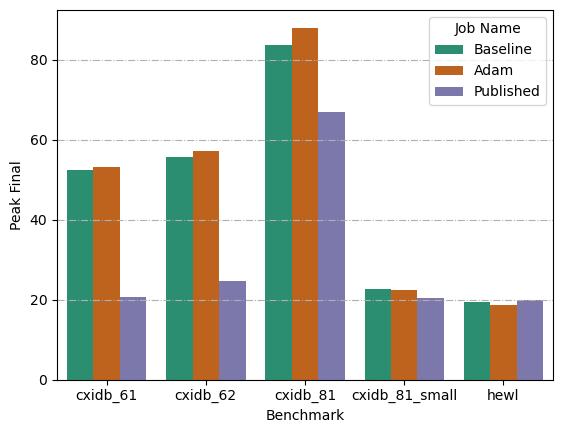

In [22]:
xkey = 'Benchmark'
ykey = 'Peak Final'
lkey = 'Job Name'

literature_csv = f""""{lkey}",Benchmark,"{ykey}"
Published,cxidb_61,20.6
Published,cxidb_62,24.6
Published,cxidb_81,67.0
Published,cxidb_81_small,20.42
Published,hewl,19.89"""
from io import StringIO
df = pd.concat((
    jr.results,
    pd.read_csv(StringIO(literature_csv)),
))

sns.barplot(
    df.melt((xkey, lkey), value_vars=ykey).sort_values(xkey),
    x=xkey,
    y='value',
    hue=lkey,
    palette='Dark2',
)
plt.ylabel(ykey)
plt.grid(which='both', axis='y', ls='-.')

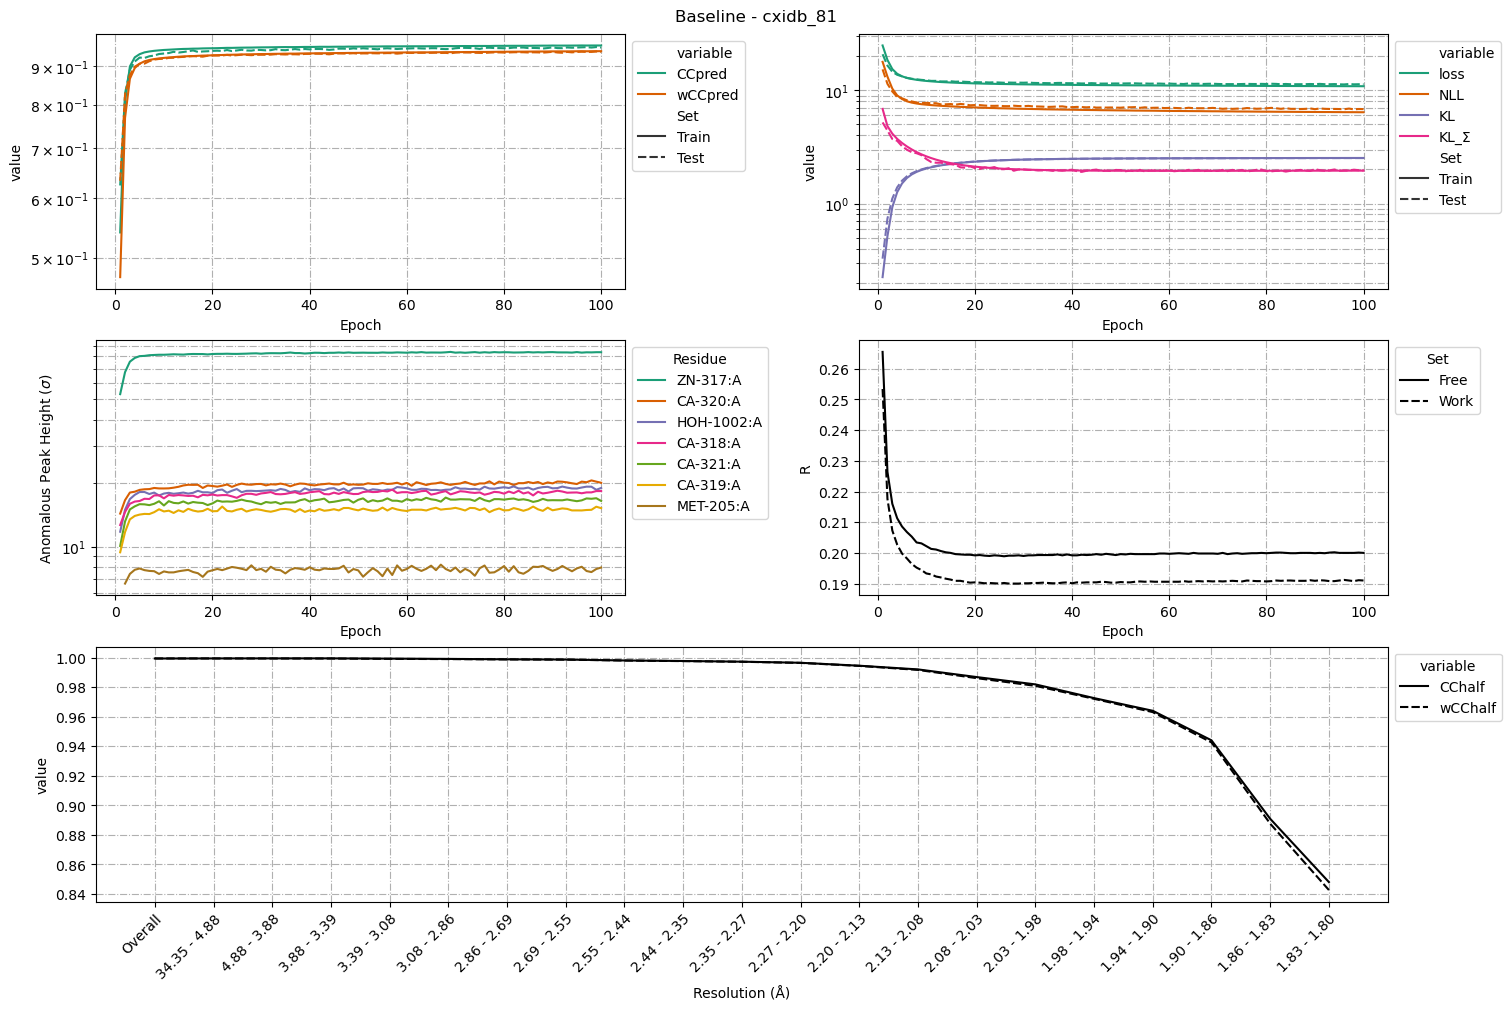

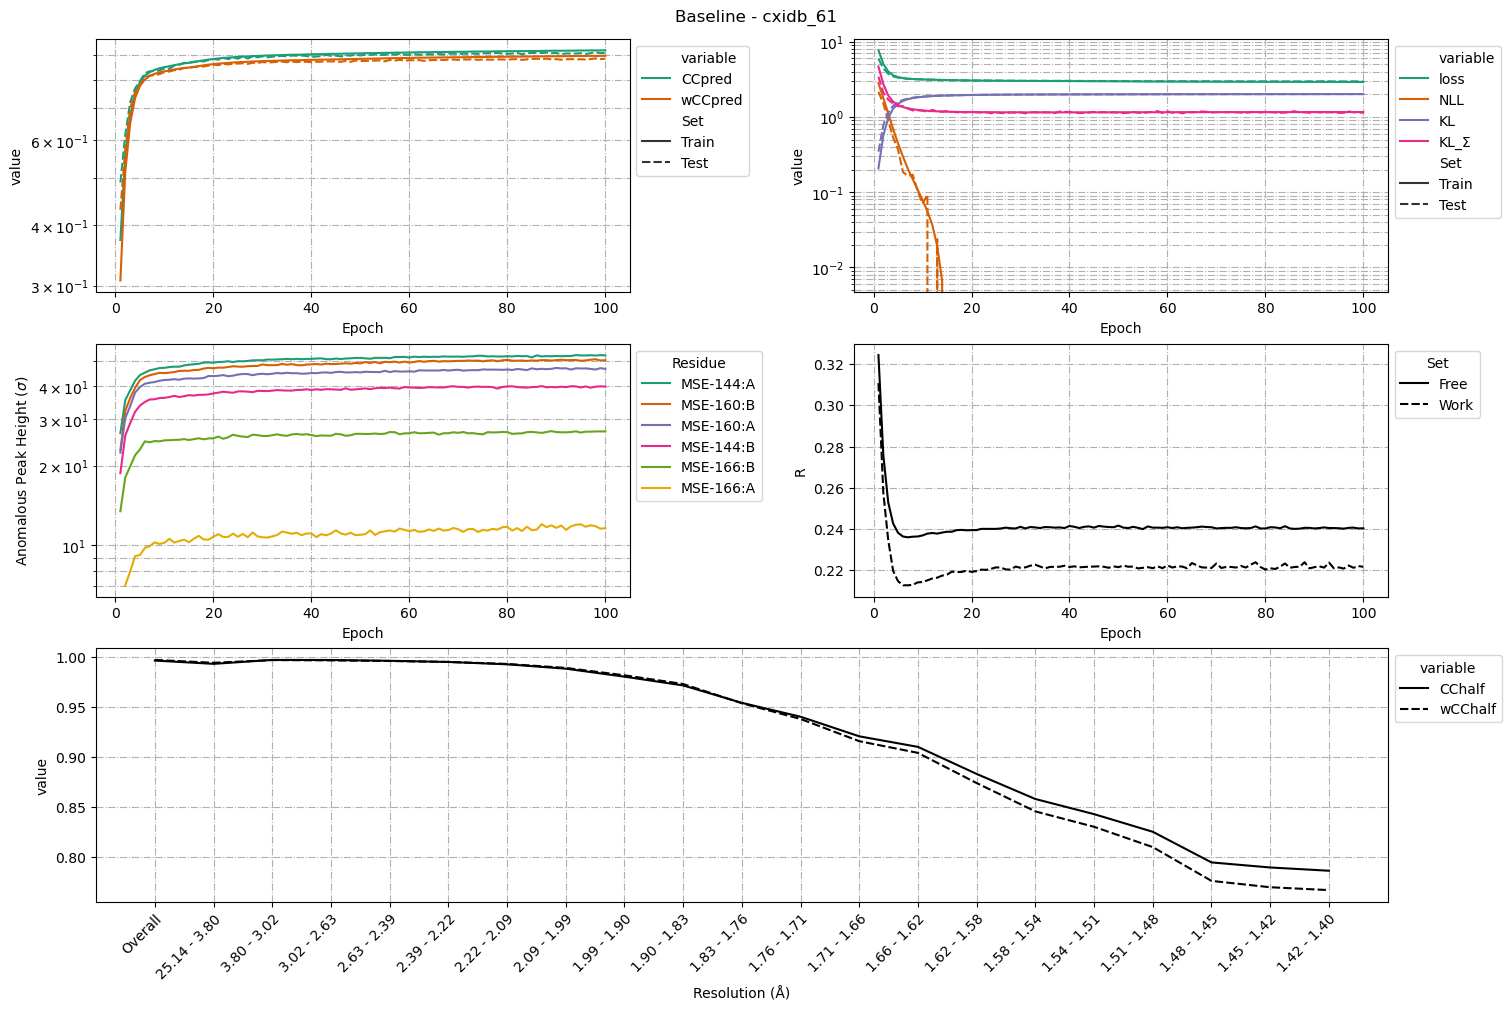

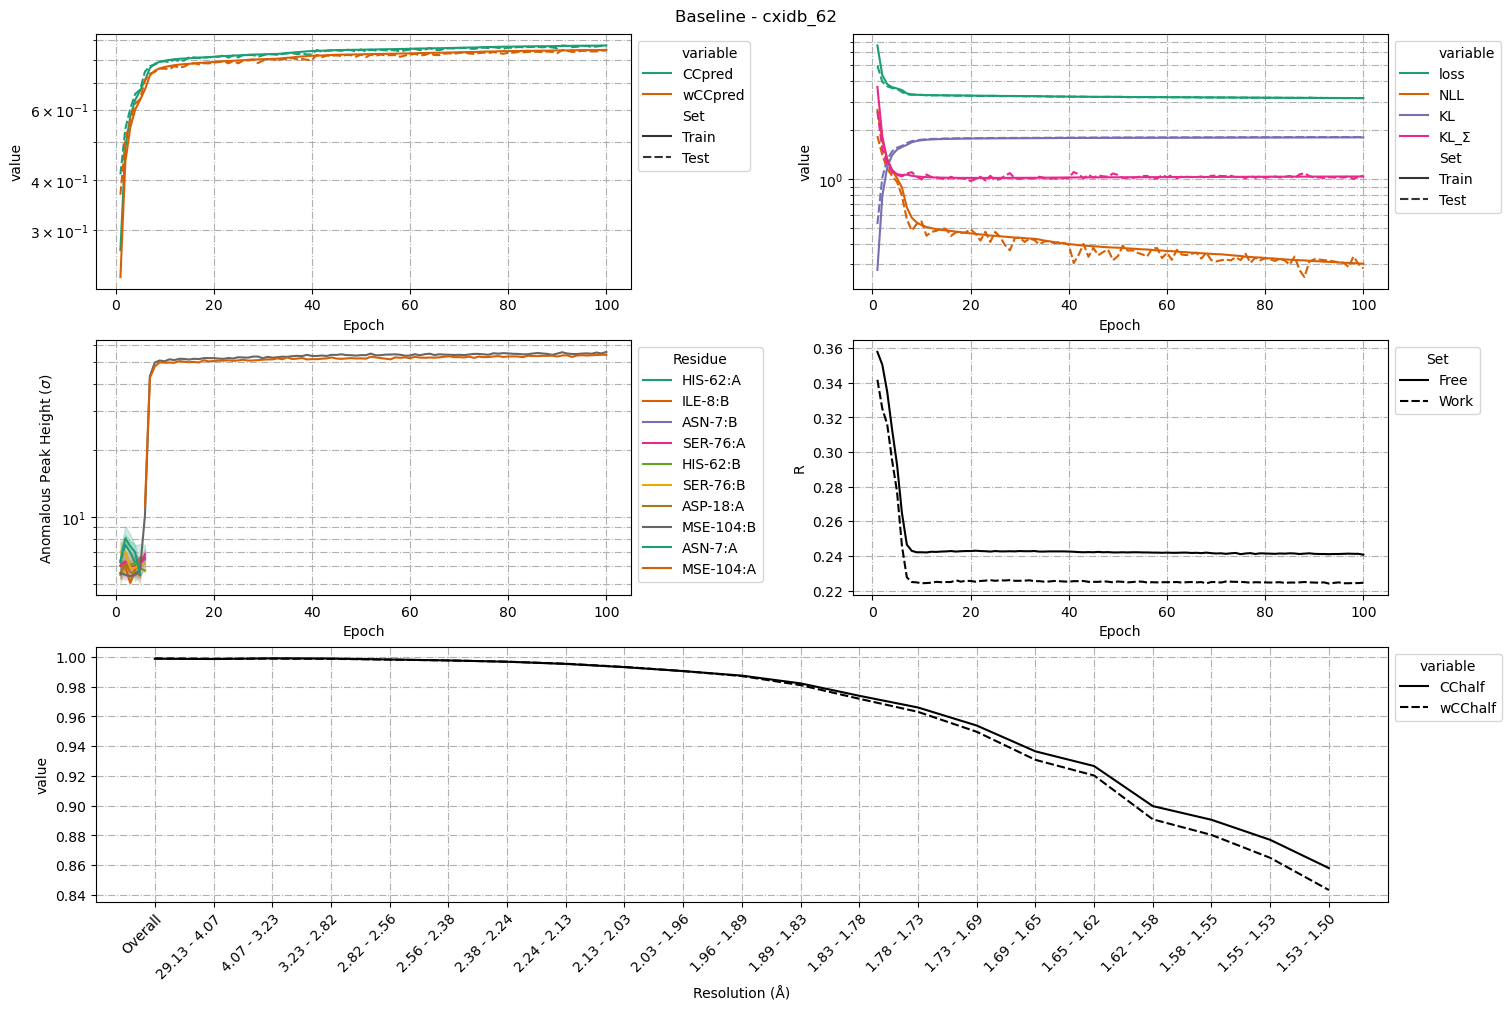

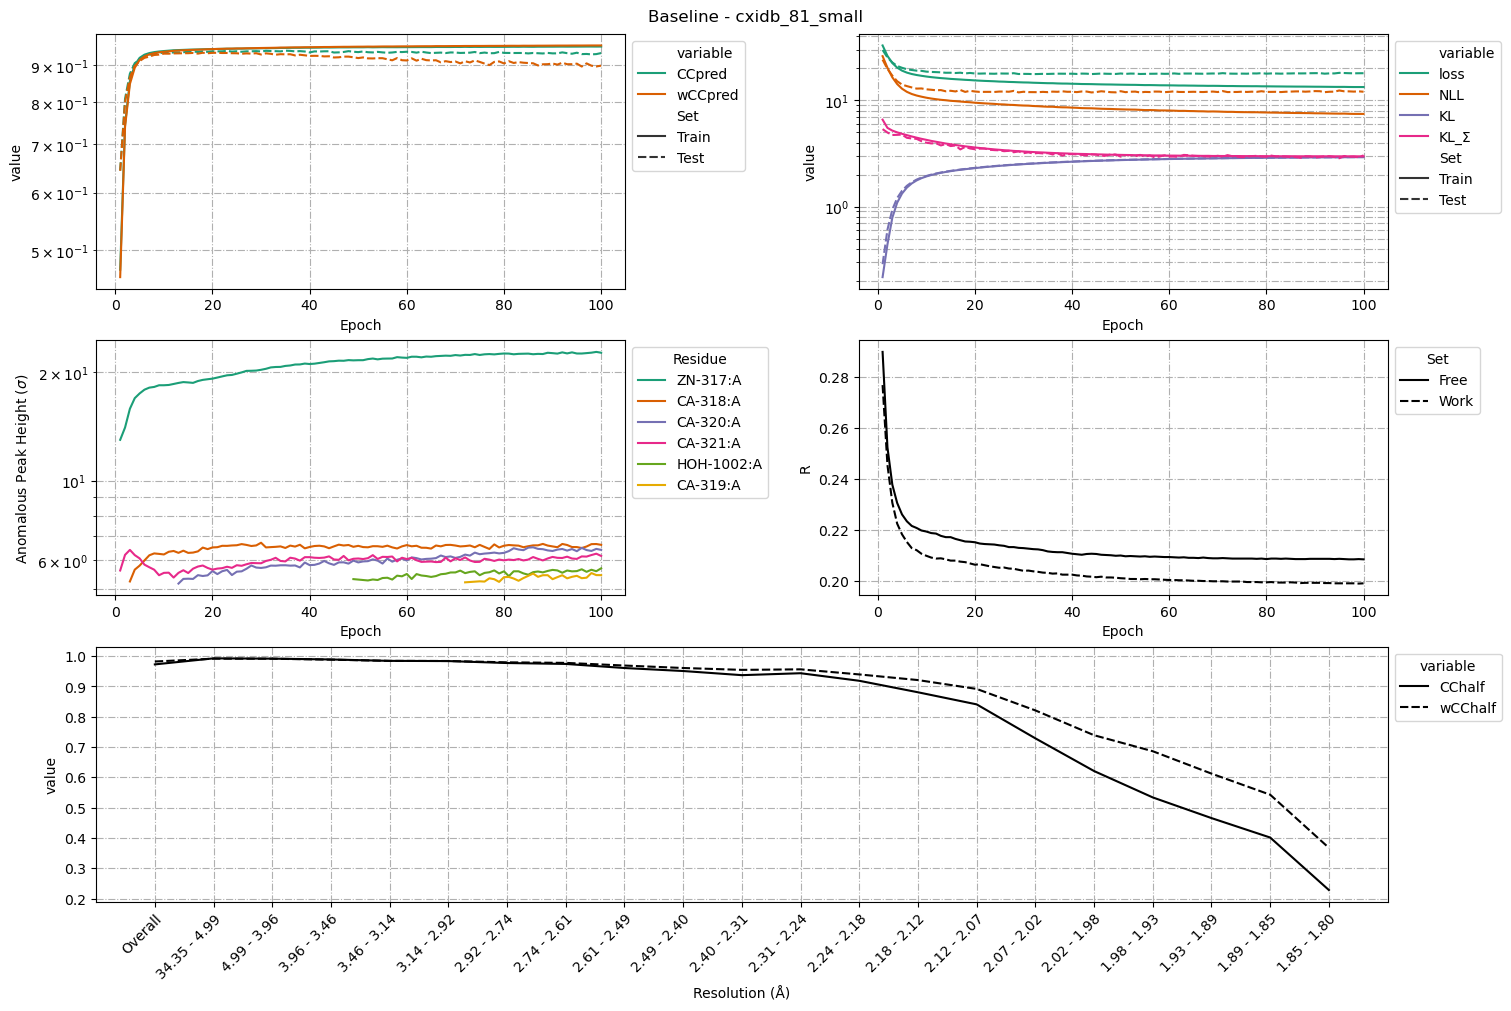

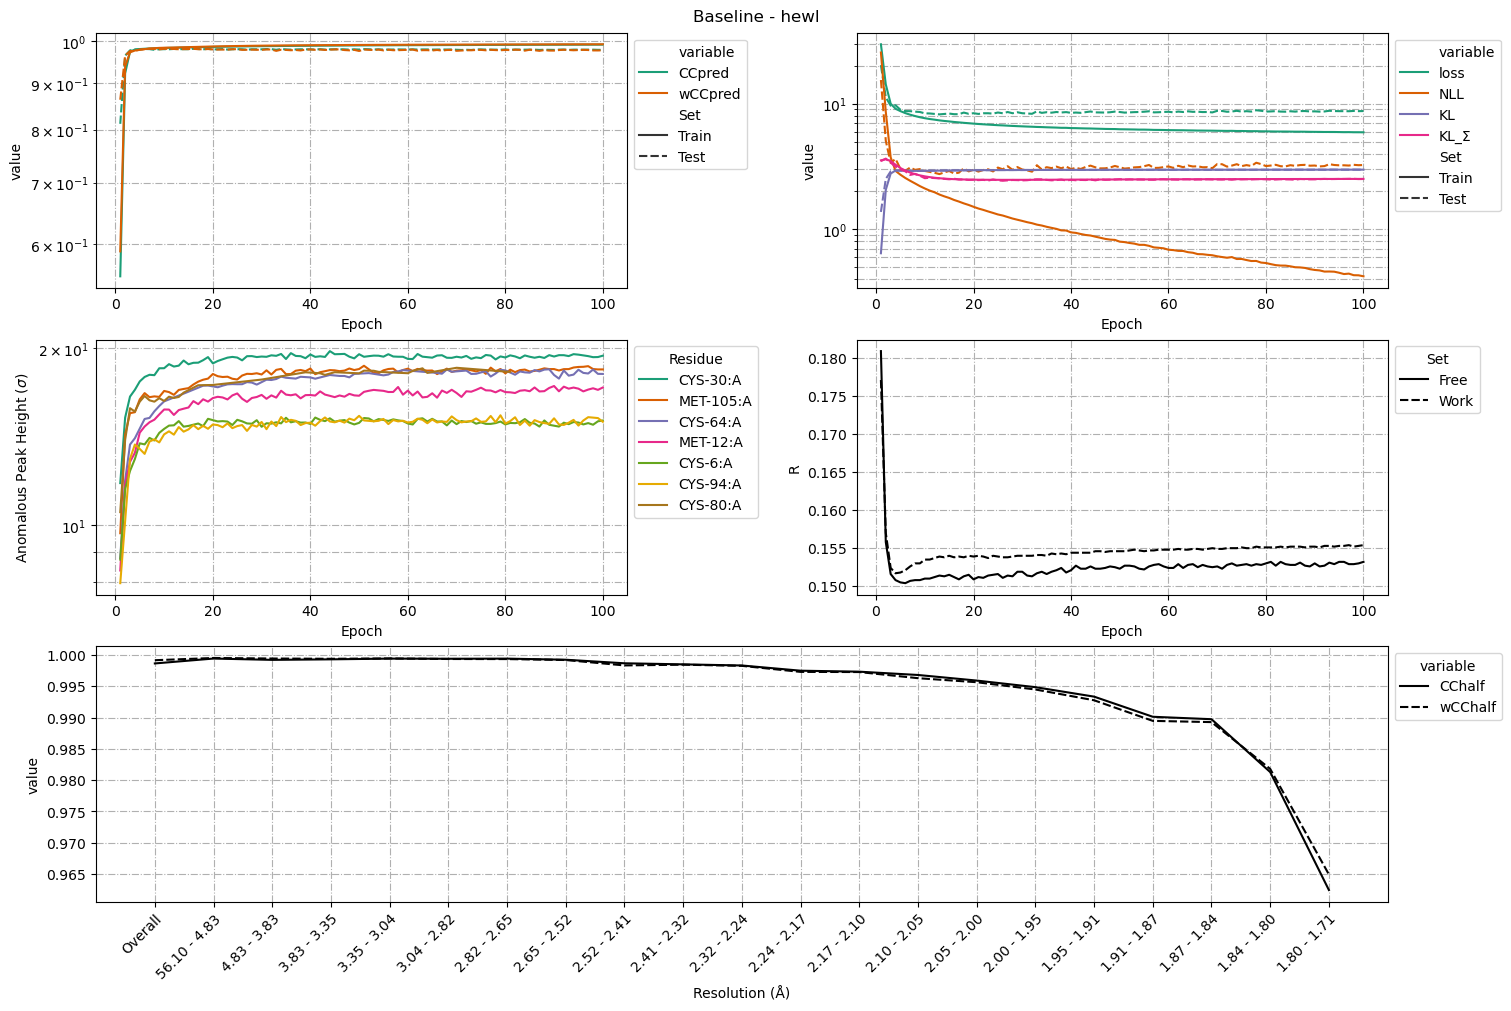

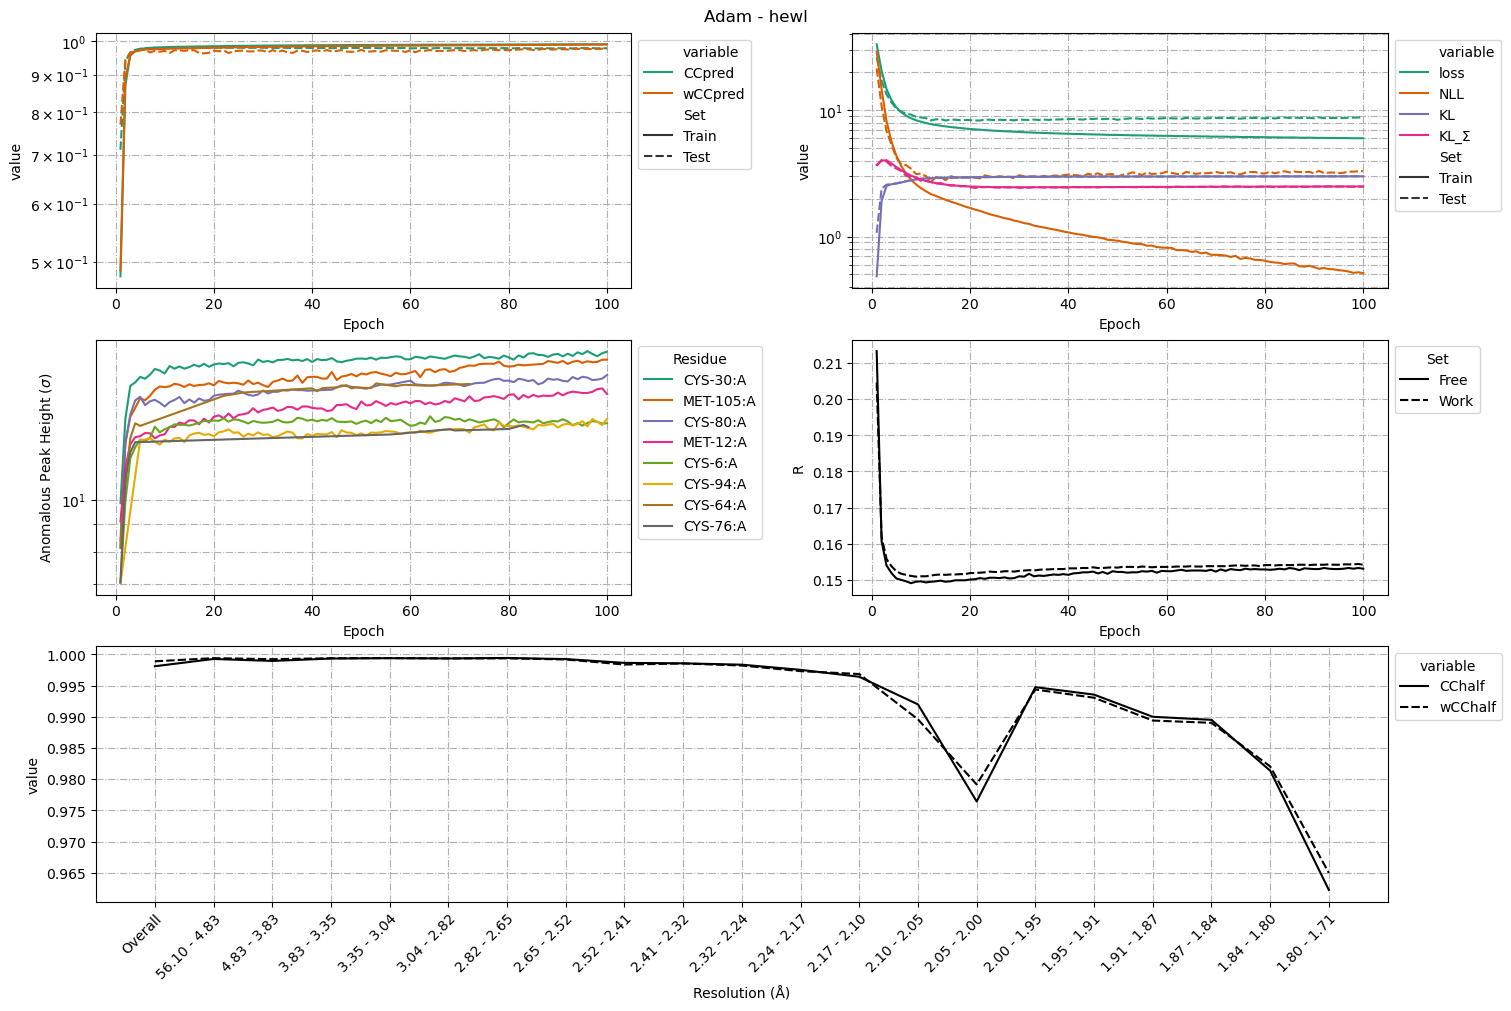

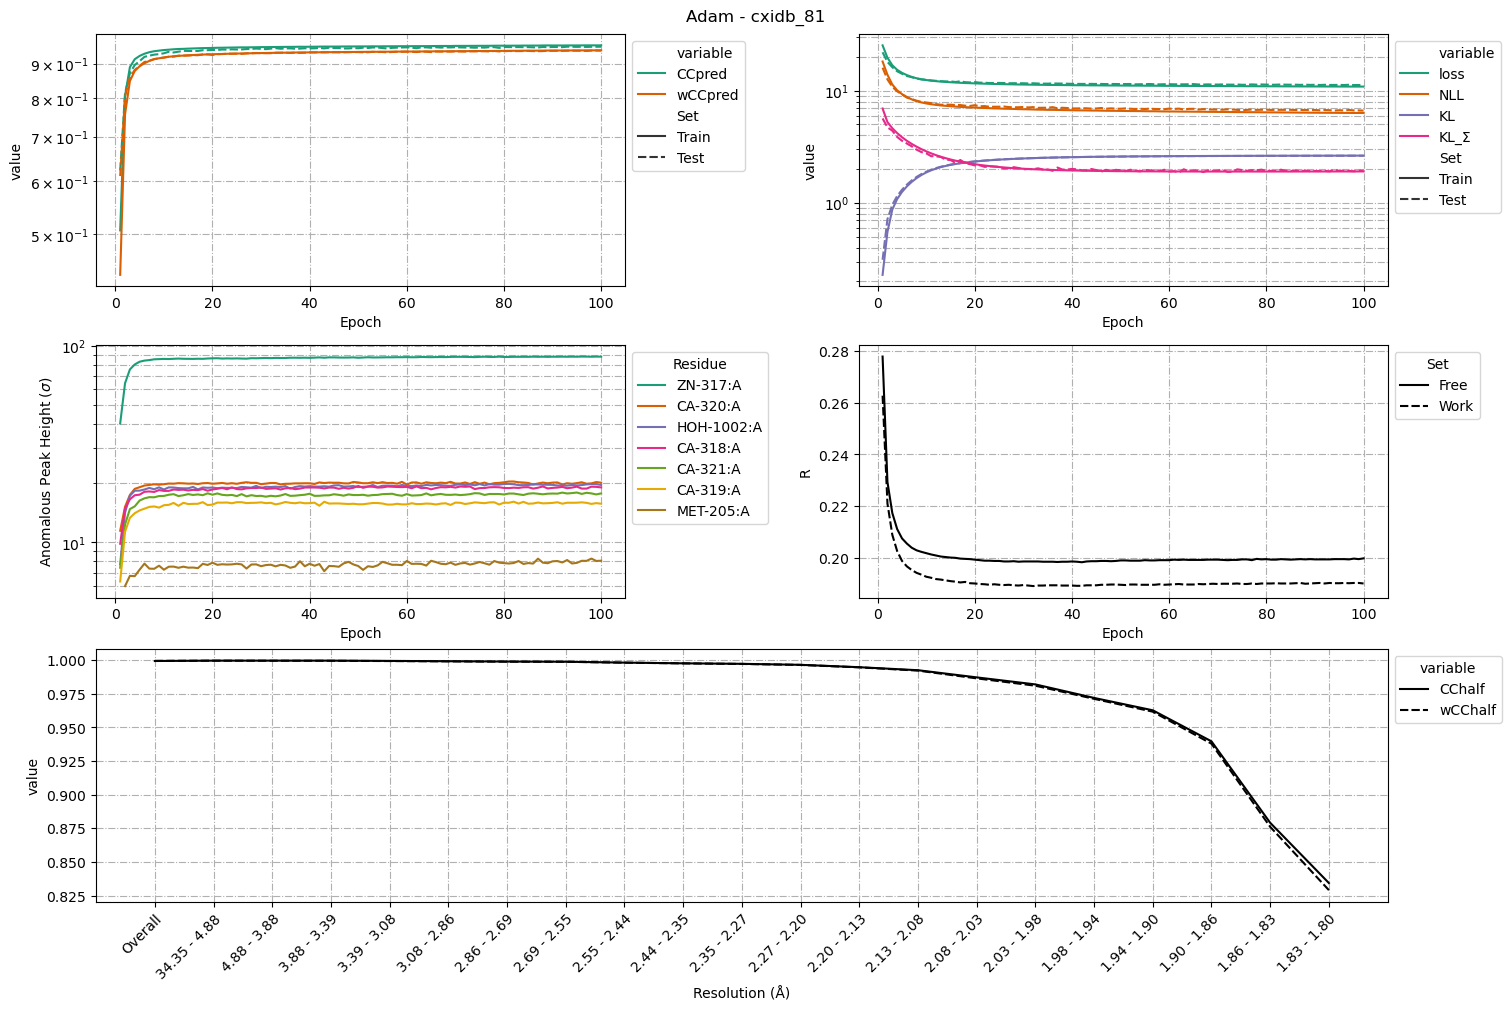

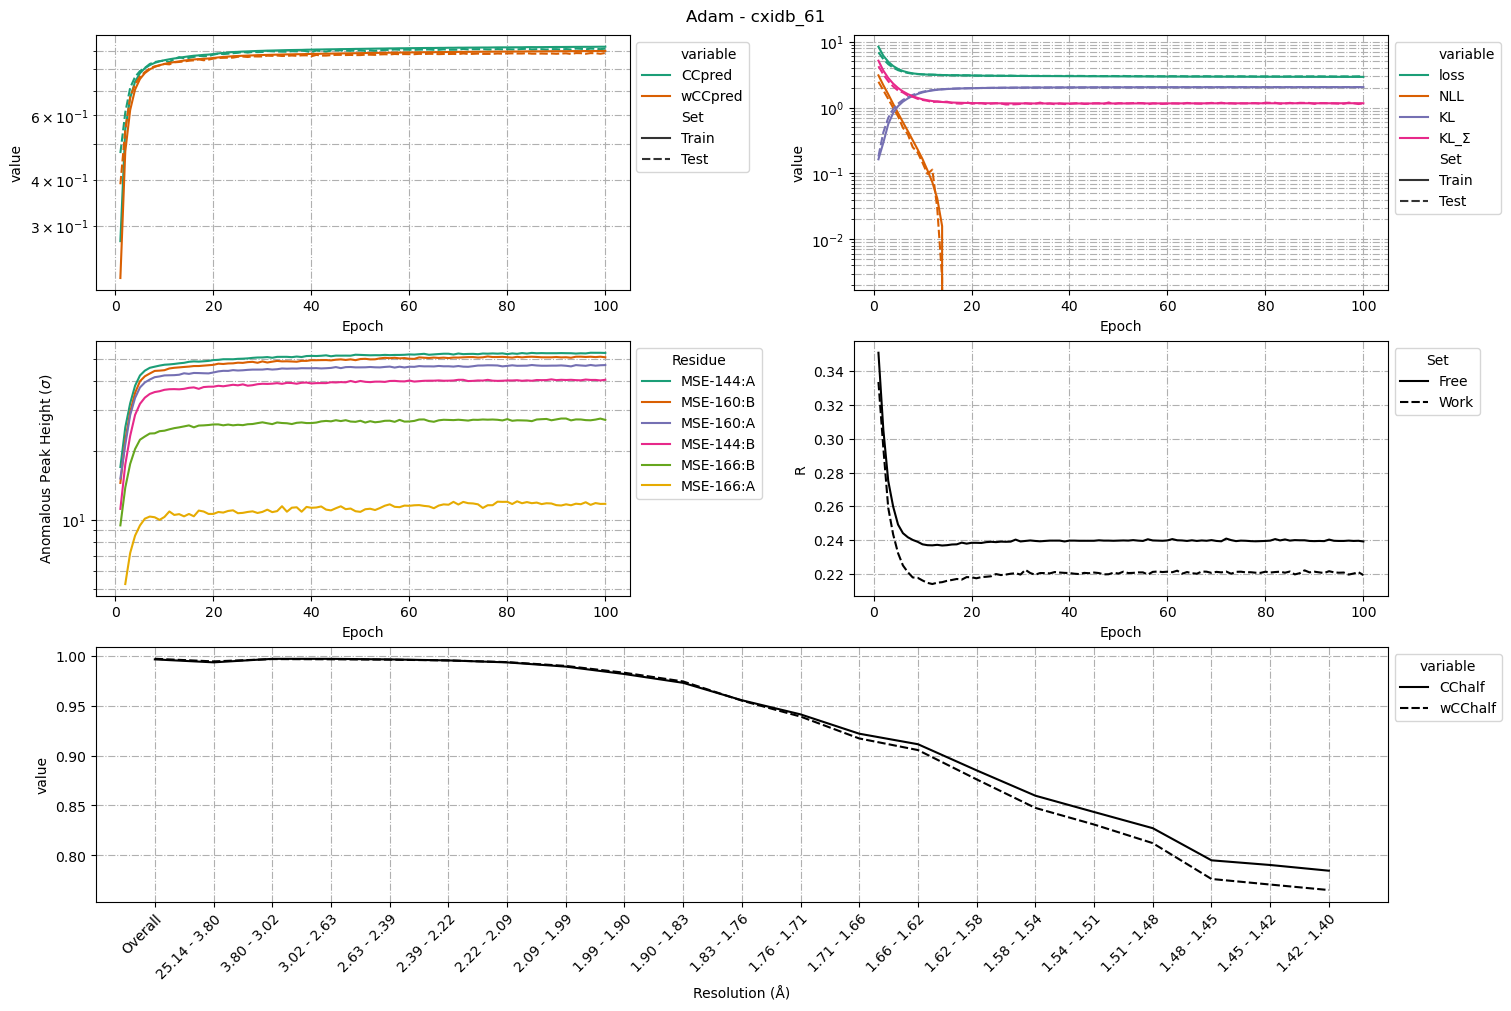

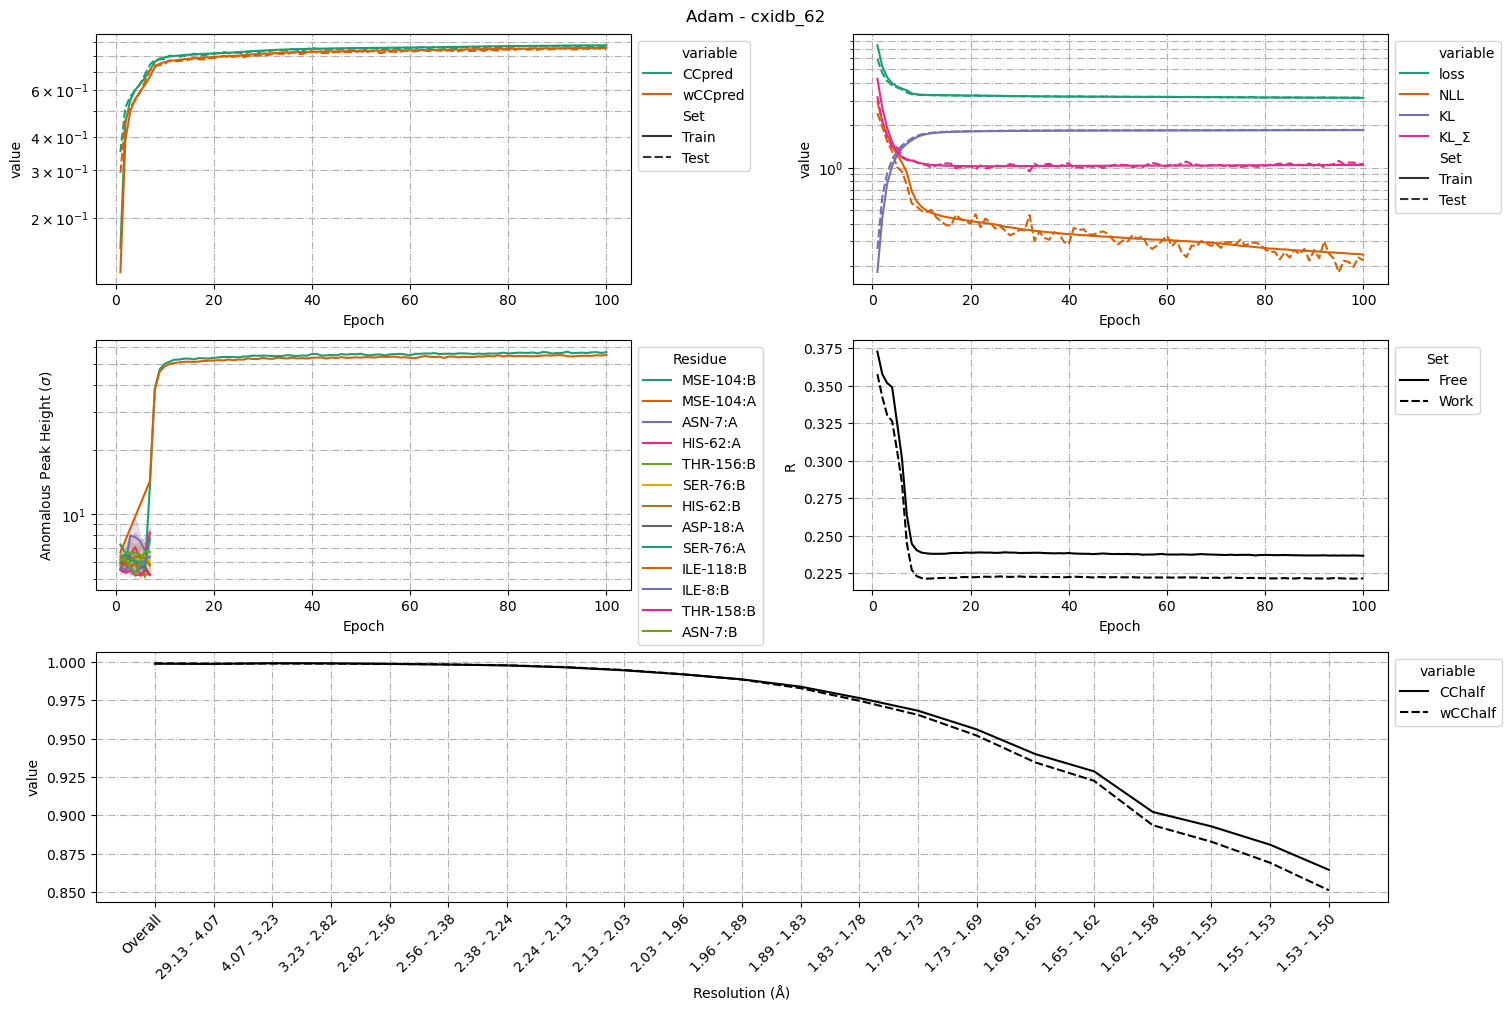

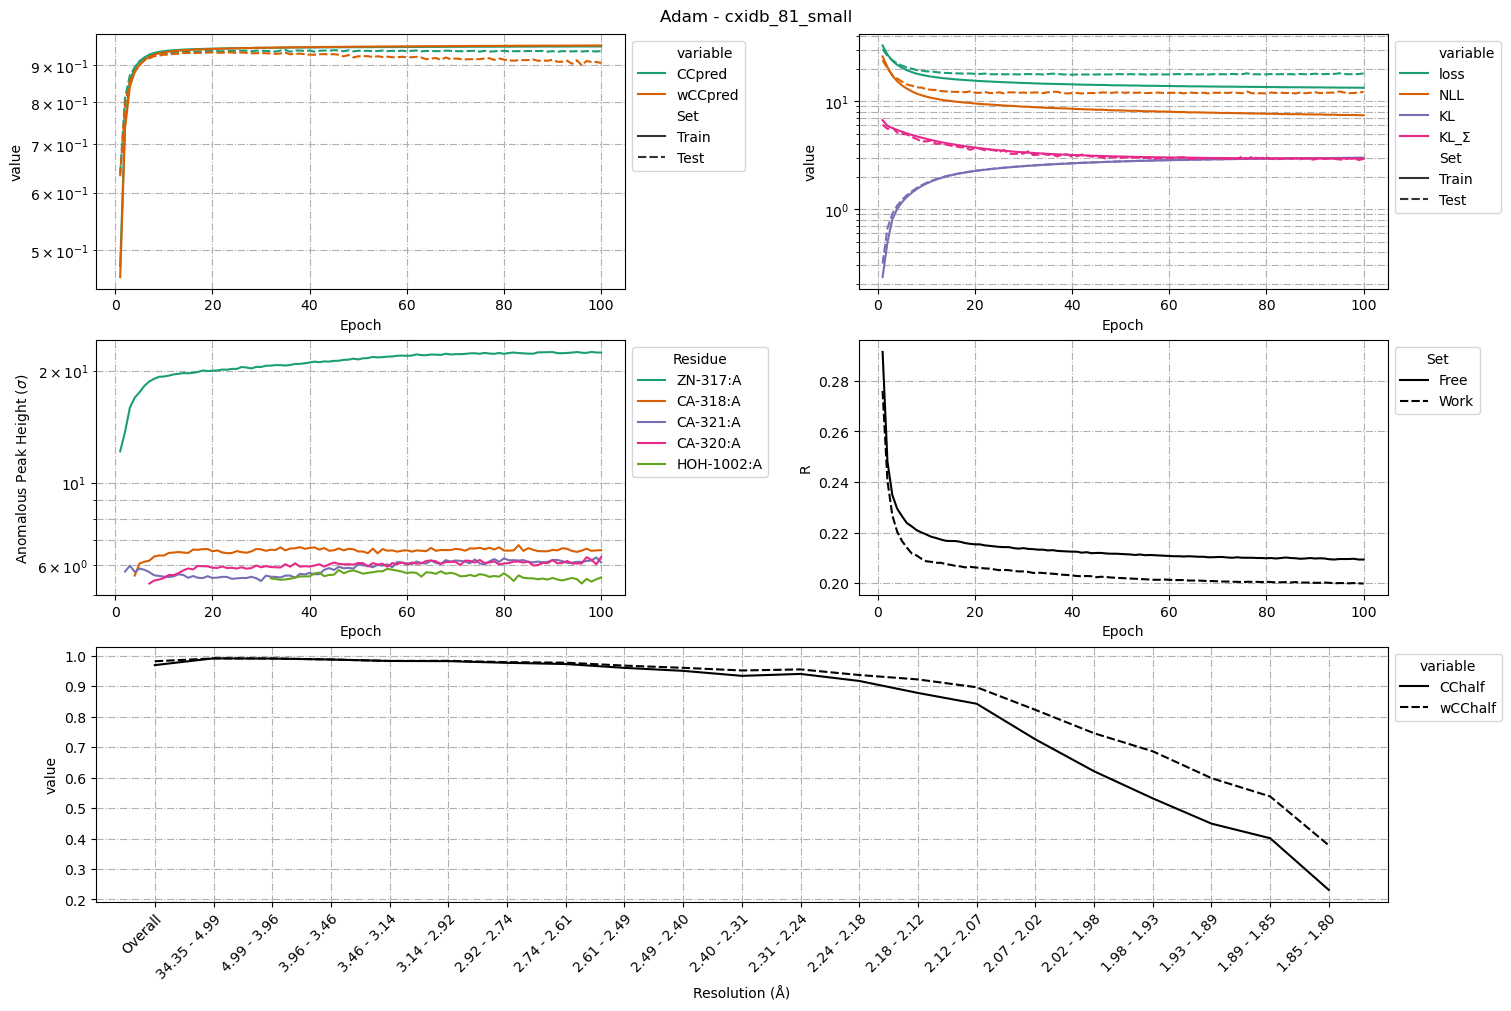

In [24]:
for br in jr.reports:
    br._do_plots()

In [6]:
literature_peak_max = {
    'cxidb_61' : 20.6,
    'cxidb_62' : 24.6,
    'cxidb_81' : 67.0,
    'cxidb_81_small' : 20.42,
    'hewl' : 19.89, #Aimless
    #'HEWL' : 16.13, #Careless without transfer learning
    #'HEWL' : 20.48, #Careless with transfer learning
} 

records = []
for _,row in jr.results.iterrows():
    k = row['Benchmark']
    if k in literature_peak_max:
        row['Published Peak'] = literature_peak_max[k]
        records.append(row)

df = pd.DataFrame.from_records(records)
df[r'Peak Change ($\sigma$)'] = df['Peak Final'] - df['Published Peak']
df[r'Peak Change (%)'] = 100.*(df['Peak Final'] - df['Published Peak']) / df['Published Peak']
df


,Job,Benchmark,CChalf,wCChalf,Peak Final,Peak Max,Rfree Min,Rfree Final,Rwork Min,Rwork Final,...,CCpred (Test) Final,wCCpred (Test) Final,Runtime (s),Runtime (HH:MM:SS),Memory Usage (MB),name,Job Name,Published Peak,Peak Change ($\sigma$),Peak Change (%)
0,16491256,cxidb_81,0.999442,0.999475,83.677577,83.945121,0.1989,0.2000,0.1900,0.1910,...,0.952992,0.940381,5999.893333,01:39:59,2506,Baseline,Baseline,67.00,16.677577,24.891906
1,16491256,cxidb_61,0.996127,0.996776,52.383080,52.487221,0.2359,0.2403,0.2126,0.2216,...,0.908218,0.884162,8467.642547,02:21:07,4534,Baseline,Baseline,20.60,31.783080,154.286795
2,16491256,cxidb_62,0.998707,0.998916,55.588697,55.588697,0.2407,0.2407,0.2240,0.2245,...,0.868879,0.844996,22371.355786,06:12:51,8630,Baseline,Baseline,24.60,30.988697,125.970314
3,16491256,cxidb_81_small,0.972640,0.982201,22.698221,22.817011,0.2085,0.2085,0.1990,0.1991,...,0.936162,0.899447,5072.147188,01:24:32,2506,Baseline,Baseline,20.42,2.278221,11.156811
4,16491256,hewl,0.998632,0.999147,19.424165,19.773797,0.1504,0.1532,0.1517,0.1554,...,0.978595,0.977354,2997.243350,00:49:57,1460,Baseline,Baseline,19.89,-0.465835,-2.342058
